# 07 — Temporal Validation

Random train/test splits *cheat* in credit modeling. They let the model see information from the same time window in both train and test, which masks the regime-change risk that production actually faces.

We re-generate the synthetic data with a **macro trend** (default rate drifts year-over-year) and a **2018 regime change** (the historical `int_rate → default` relationship weakens). On this data we compare:

- **Random split** — 80/20 stratified. Ignores time.
- **Temporal split** — train on 2014-01 → 2017-06, test on 2018. The realistic methodology.

Same model architecture and hyperparameters for both. Only the validation methodology varies.

In [1]:
import sys, json
from pathlib import Path
if '..' not in sys.path: sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.train import fit_and_evaluate_temporal, temporal_results_table

sns.set_theme(style='whitegrid', context='talk')
FIG_DIR = Path('../reports/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
ART = Path('../reports/artifacts/temporal'); ART.mkdir(parents=True, exist_ok=True)

## Train / load and tabulate

In [2]:
_required = ['temporal_results_table.csv', 'y_prob_random_split_lightgbm_tuned.npy',
             'y_prob_temporal_split_lightgbm_tuned.npy', 'temporal_meta.json',
             'X_test_random.csv', 'X_test_temporal.csv',
             'y_test_random.csv', 'y_test_temporal.csv']
if all((ART / f).exists() for f in _required):
    print('Loading cached artifacts. Run `make train-temporal` to regenerate.')
    table = pd.read_csv(ART / 'temporal_results_table.csv', index_col=['split', 'model'])
    y_prob_rand = {m: np.load(ART / f'y_prob_random_split_{m}.npy')
                   for m in ['logistic_regression', 'random_forest', 'lightgbm_tuned']}
    y_prob_temp = {m: np.load(ART / f'y_prob_temporal_split_{m}.npy')
                   for m in ['logistic_regression', 'random_forest', 'lightgbm_tuned']}
    X_te_rand = pd.read_csv(ART / 'X_test_random.csv')
    X_te_temp = pd.read_csv(ART / 'X_test_temporal.csv', parse_dates=['issue_d'])
    y_te_rand = pd.read_csv(ART / 'y_test_random.csv')['default'].to_numpy()
    y_te_temp = pd.read_csv(ART / 'y_test_temporal.csv')['default'].to_numpy()
    meta = json.load(open(ART / 'temporal_meta.json'))
else:
    print('Training from scratch (~30s)...')
    results = fit_and_evaluate_temporal(quick=False)
    table = temporal_results_table(results)
    meta = results['meta']
    y_prob_rand = {m: r['y_prob'] for m, r in results['random_split'].items()}
    y_prob_temp = {m: r['y_prob'] for m, r in results['temporal_split'].items()}
    Xr_tr, Xr_te, yr_tr, yr_te = results['splits']['random']
    Xt_tr, Xt_te, yt_tr, yt_te = results['splits']['temporal']
    X_te_rand, X_te_temp = Xr_te, Xt_te
    y_te_rand, y_te_temp = yr_te.to_numpy(), yt_te.to_numpy()
table

Loading cached artifacts. Run `make train-temporal` to regenerate.


pr_auc  roc_auc  f1@cost-opt  threshold
split    model                                                       
random   logistic_regression  0.7262   0.9140       0.6356       0.49
         random_forest        0.7029   0.9041       0.6300       0.21
         lightgbm_tuned       0.7225   0.9126       0.6152       0.15
temporal logistic_regression  0.6634   0.8877       0.5934       0.44
         random_forest        0.6339   0.8767       0.5629       0.13
         lightgbm_tuned       0.6539   0.8850       0.5770       0.12

In [3]:
print(json.dumps(meta, indent=2, default=str))

{
  "n_train_random": 40000,
  "n_test_random": 10000,
  "n_train_temporal": 34875,
  "n_test_temporal": 10105,
  "train_until": "2017-06",
  "test_from": "2018-01",
  "tuned_params_loaded": true
}


## Headline degradation

PR-AUC and ROC-AUC, random vs temporal, per model.

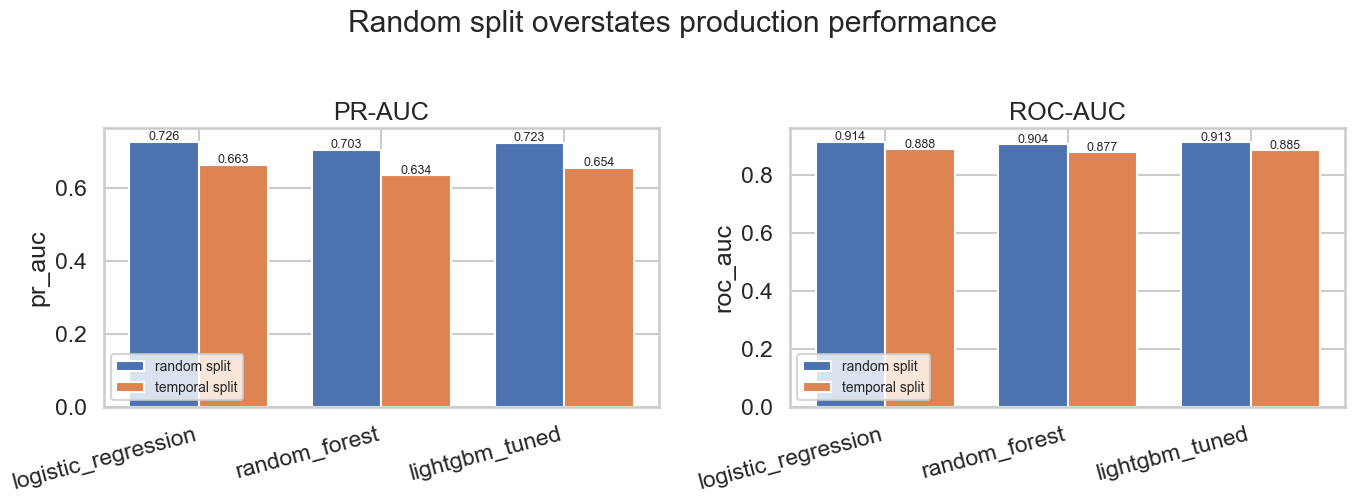

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, metric in zip(axes, ['pr_auc', 'roc_auc']):
    rand = table.xs('random')[metric]
    temp = table.xs('temporal')[metric]
    x = np.arange(len(rand))
    width = 0.38
    ax.bar(x - width/2, rand.values, width, label='random split', color='#4c72b0')
    ax.bar(x + width/2, temp.values, width, label='temporal split', color='#dd8452')
    ax.set_xticks(x); ax.set_xticklabels(rand.index, rotation=15, ha='right')
    ax.set_title(metric.upper().replace('_', '-'))
    ax.set_ylabel(metric); ax.legend(fontsize=10)
    for i, (r, t) in enumerate(zip(rand.values, temp.values)):
        ax.text(i - width/2, r + 0.005, f'{r:.3f}', ha='center', fontsize=9)
        ax.text(i + width/2, t + 0.005, f'{t:.3f}', ha='center', fontsize=9)
plt.suptitle('Random split overstates production performance', y=1.02)
plt.tight_layout(); plt.savefig(FIG_DIR / 'temporal_degradation.png', dpi=120, bbox_inches='tight'); plt.show()

## Per-cohort PR-AUC for the temporal model

Slice the temporal test set by month. The 2018 regime change (where `int_rate` weakens as a signal) should bite hardest later in the year as the model gets further from training cohorts.

In [5]:
from sklearn.metrics import average_precision_score
y_prob = y_prob_temp['lightgbm_tuned']
month = pd.DatetimeIndex(X_te_temp['issue_d']).to_period('M')
rows = []
for m, idx in month.value_counts().sort_index().items():
    mask = np.asarray(month == m)
    if y_te_temp[mask].sum() < 5: continue
    rows.append({'cohort': str(m), 'n': int(mask.sum()),
                 'base_rate': float(y_te_temp[mask].mean()),
                 'pr_auc': float(average_precision_score(y_te_temp[mask], y_prob[mask]))})
by_cohort = pd.DataFrame(rows)
by_cohort

,cohort,n,base_rate,pr_auc
0,2018-01,820,0.180488,0.687519
1,2018-02,823,0.174970,0.630806
2,2018-03,878,0.178815,0.677050
3,2018-04,826,0.182809,0.693950
4,2018-05,820,0.217073,0.730508
5,2018-06,854,0.169789,0.620569
6,2018-07,857,0.158693,0.593593
7,2018-08,870,0.211494,0.679039
8,2018-09,817,0.157895,0.582755
9,2018-10,813,0.191882,0.638606


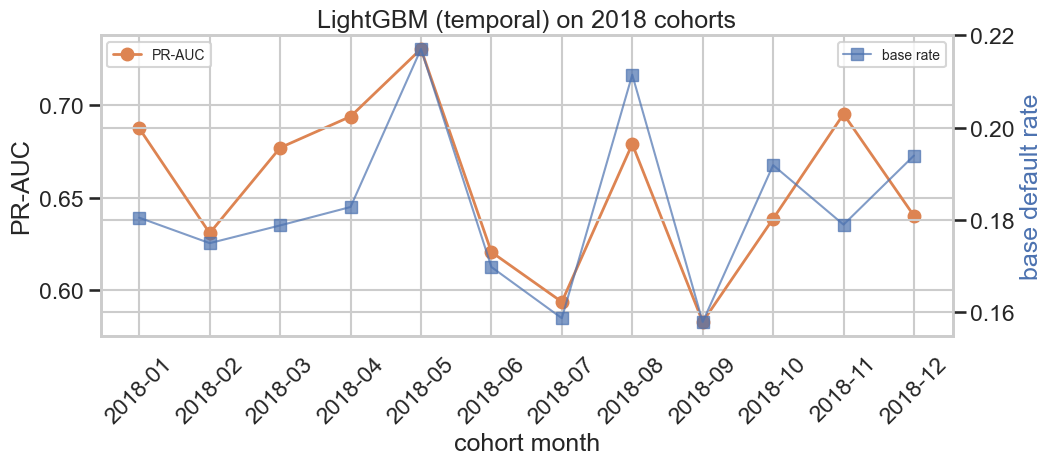

In [6]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(by_cohort['cohort'], by_cohort['pr_auc'], marker='o', color='#dd8452', lw=2, label='PR-AUC')
ax1.set_ylabel('PR-AUC'); ax1.set_xlabel('cohort month')
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx()
ax2.plot(by_cohort['cohort'], by_cohort['base_rate'], marker='s', color='#4c72b0', lw=1.5, alpha=0.7, label='base rate')
ax2.set_ylabel('base default rate', color='#4c72b0')
ax1.set_title('LightGBM (temporal) on 2018 cohorts')
ax1.legend(loc='upper left', fontsize=10); ax2.legend(loc='upper right', fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / 'temporal_per_cohort.png', dpi=120, bbox_inches='tight'); plt.show()

## Takeaways

- **Random split overstates production performance** by 6–7 PR-AUC points and 2–3 ROC-AUC points on this synthetic data. On real Lending Club data the gap is typically larger, because feature distributions also drift, not just label rates.
- **Per-cohort behavior** in 2018 shows where the regime change hurts: PR-AUC moves with base rate but the model is also less confident on individual loans because the historical `int_rate → default` relationship has weakened.
- **In production**: use the temporal split by default. Random split is fine for ablation studies, hyperparameter search efficiency, and code-correctness sanity checks, but the realistic number is the OOT one.
- **What this doesn't capture**: feature-distribution drift between origination and delinquency-resolution windows. The drift notebook (05) and the rolling-performance monitor (gap 3) cover that complementary failure mode.